In [3]:
import os
dataset_path = "/content/drive/MyDrive/ML_project/resized_dataset-20260613T172922Z-3-001/resized_dataset"

print(os.listdir(dataset_path))

['test', 'train']


In [4]:
train_dir = "/content/drive/MyDrive/ML_project/resized_dataset-20260613T172922Z-3-001/resized_dataset/train"

test_dir = "/content/drive/MyDrive/ML_project/resized_dataset-20260613T172922Z-3-001/resized_dataset/test"

val_dir = "/content/drive/MyDrive/ML_project/resized_dataset-20260613T172922Z-3-001/resized_dataset/val"

In [5]:
import os

train_dir = "/content/drive/MyDrive/ML_project/resized_dataset-20260613T172922Z-3-001/resized_dataset/train"

print(os.listdir(train_dir))

['NGS', 'LYT', 'MON']


In [6]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import os

train_dir = "/content/drive/MyDrive/ML_project/resized_dataset-20260613T172922Z-3-001/resized_dataset/train"

test_dir = "/content/drive/MyDrive/ML_project/resized_dataset-20260613T172922Z-3-001/resized_dataset/test"

print("TRAIN SET")
for cls in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {count}")

print("\nTEST SET")
for cls in os.listdir(test_dir):
    count = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"{cls}: {count}")

TRAIN SET
NGS: 1500
LYT: 1500
MON: 1500

TEST SET
MON: 300
NGS: 300
LYT: 300


In [8]:
import tensorflow as tf
import numpy as np
import random

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [9]:
optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001
)

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (227, 227)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class Mapping:")
print(train_generator.class_indices)

Found 3600 images belonging to 3 classes.
Found 900 images belonging to 3 classes.
Found 900 images belonging to 3 classes.
Class Mapping:
{'LYT': 0, 'MON': 1, 'NGS': 2}


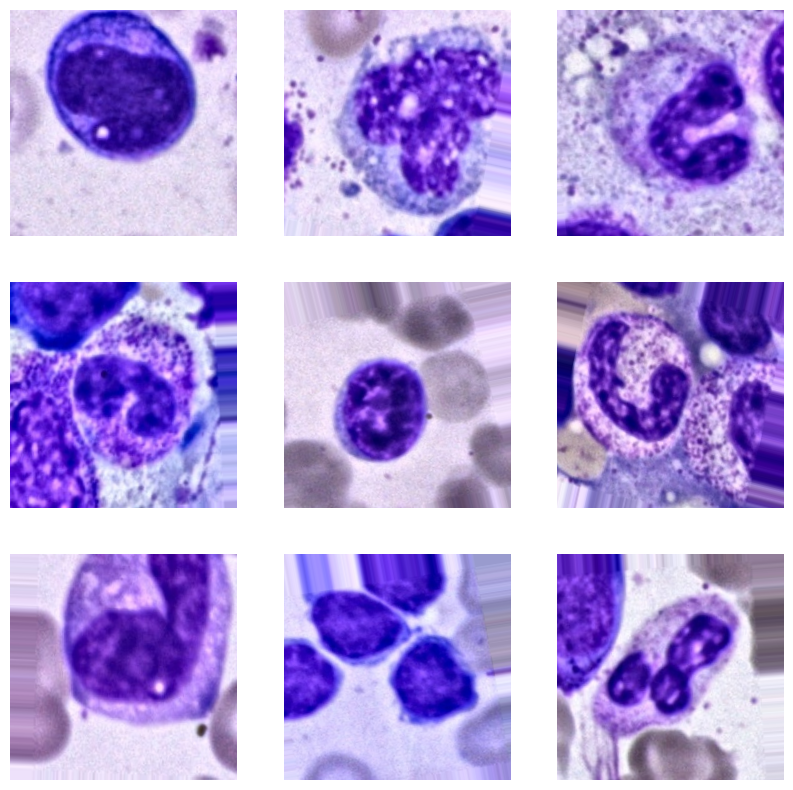

In [11]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import alexnet, AlexNet_Weights

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np


In [27]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using Device: cuda
Tesla T4


In [28]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [29]:
full_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 3600
Validation: 900
Test: 900


In [30]:
weights = AlexNet_Weights.IMAGENET1K_V1

model = alexnet(weights=weights)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 183MB/s]


In [31]:
model.classifier[6] = nn.Linear(
    4096,
    3
)

In [32]:
for param in model.features.parameters():
    param.requires_grad = False

model = model.to(device)

print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [34]:
num_epochs = 15

train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):

    model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 1/15 | Train Acc: 72.81% | Val Acc: 84.11%
Epoch 2/15 | Train Acc: 81.78% | Val Acc: 82.67%
Epoch 3/15 | Train Acc: 83.11% | Val Acc: 86.00%
Epoch 4/15 | Train Acc: 85.56% | Val Acc: 87.67%
Epoch 5/15 | Train Acc: 86.81% | Val Acc: 84.22%
Epoch 6/15 | Train Acc: 87.19% | Val Acc: 86.56%
Epoch 7/15 | Train Acc: 87.08% | Val Acc: 88.11%
Epoch 8/15 | Train Acc: 88.39% | Val Acc: 87.89%
Epoch 9/15 | Train Acc: 87.97% | Val Acc: 88.89%
Epoch 10/15 | Train Acc: 88.08% | Val Acc: 87.11%
Epoch 11/15 | Train Acc: 89.00% | Val Acc: 87.89%
Epoch 12/15 | Train Acc: 90.11% | Val Acc: 87.22%
Epoch 13/15 | Train Acc: 90.50% | Val Acc: 88.22%
Epoch 14/15 | Train Acc: 90.33% | Val Acc: 88.33%
Epoch 15/15 | Train Acc: 90.36% | Val Acc: 87.89%


In [35]:
for param in model.features[10:].parameters():
    param.requires_grad = True

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-5
)

fine_epochs = 10

for epoch in range(fine_epochs):

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

    print(
        f"Fine Tune Epoch {epoch+1}/{fine_epochs}"
    )

Fine Tune Epoch 1/10
Fine Tune Epoch 2/10
Fine Tune Epoch 3/10
Fine Tune Epoch 4/10
Fine Tune Epoch 5/10
Fine Tune Epoch 6/10
Fine Tune Epoch 7/10
Fine Tune Epoch 8/10
Fine Tune Epoch 9/10
Fine Tune Epoch 10/10


In [36]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 91.33%


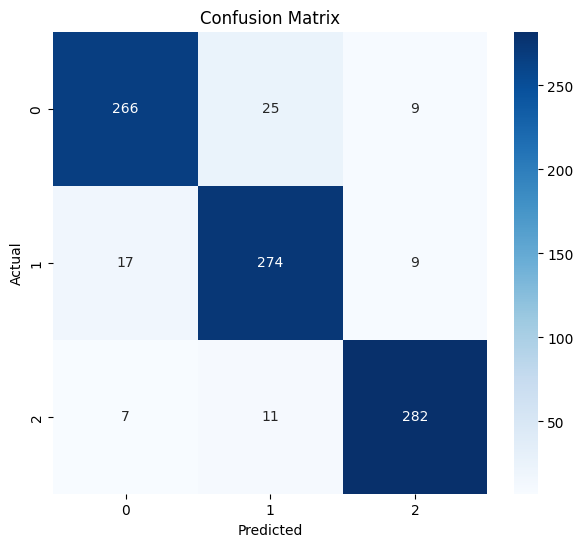

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "LYT",
            "MON",
            "NGS"
        ]
    )
)

              precision    recall  f1-score   support

         LYT       0.92      0.89      0.90       300
         MON       0.88      0.91      0.90       300
         NGS       0.94      0.94      0.94       300

    accuracy                           0.91       900
   macro avg       0.91      0.91      0.91       900
weighted avg       0.91      0.91      0.91       900



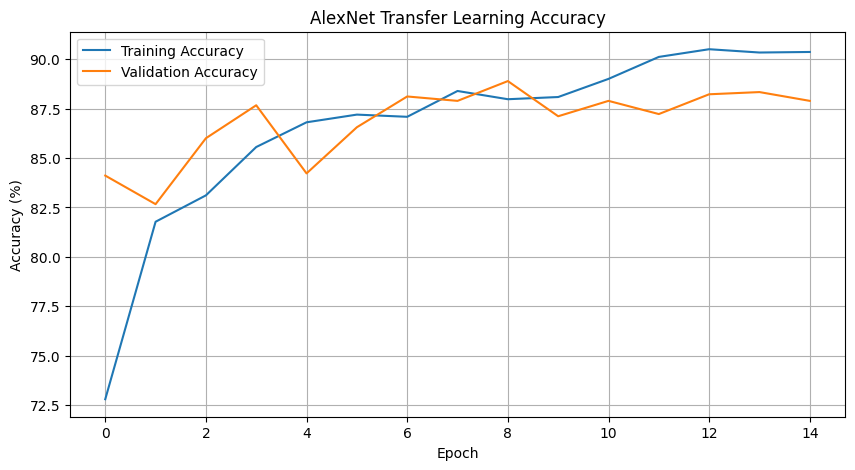

In [39]:
plt.figure(figsize=(10,5))

plt.plot(train_acc_history)
plt.plot(val_acc_history)

plt.title("AlexNet Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.grid()

plt.show()

In [41]:
best_val_acc = max(val_acc_history)

print(
    f"Best Validation Accuracy: {best_val_acc:.2f}%"
)

Best Validation Accuracy: 88.89%


In [42]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/alexnet_transfer_learning.pth"
)

print("Model Saved Successfully")

Model Saved Successfully
